# Introduction
Another chapter in my Kaggle competitons era. This notebook tries to apply what I've learned so far about building an elementary ML model.

#### **Evaluation Metric**

Submissions are evaluated based on their classification accuracy, the percentage of predicted labels that are correct.

**Results:**
- V1: 16843.63326




### Imports

In [136]:
# Core
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import make_column_transformer
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error

from sklearn.linear_model import Lasso
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

from tensorflow import keras
from keras import layers
from keras import callbacks

# Data Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Reading Data Inputs

In [137]:
# !unzip data/home-data-for-ml-course.zip -d data/

test = pd.read_csv("data/test.csv")
train = pd.read_csv("data/train.csv")
pd.set_option("display.max_rows", None)

# 1. Exploratory Data Analysis
## 1.1 Preliminary Observations

In [138]:
print("train: ", train.shape)
train.head(5)

train:  (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [139]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [140]:
train.isna().mean().sort_values(ascending=False)

PoolQC           0.995205
MiscFeature      0.963014
Alley            0.937671
Fence            0.807534
MasVnrType       0.597260
FireplaceQu      0.472603
LotFrontage      0.177397
GarageYrBlt      0.055479
GarageCond       0.055479
GarageType       0.055479
GarageFinish     0.055479
GarageQual       0.055479
BsmtFinType2     0.026027
BsmtExposure     0.026027
BsmtQual         0.025342
BsmtCond         0.025342
BsmtFinType1     0.025342
MasVnrArea       0.005479
Electrical       0.000685
Id               0.000000
Functional       0.000000
Fireplaces       0.000000
KitchenQual      0.000000
KitchenAbvGr     0.000000
BedroomAbvGr     0.000000
HalfBath         0.000000
FullBath         0.000000
BsmtHalfBath     0.000000
TotRmsAbvGrd     0.000000
GarageCars       0.000000
GrLivArea        0.000000
GarageArea       0.000000
PavedDrive       0.000000
WoodDeckSF       0.000000
OpenPorchSF      0.000000
EnclosedPorch    0.000000
3SsnPorch        0.000000
ScreenPorch      0.000000
PoolArea    

In [141]:
print("test: ", test.shape)
test.head(5)

test:  (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [142]:
print(test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [143]:
# List of numerical features
num_features = train.select_dtypes(exclude='object').copy()
print("Number of numerical features: ", len(num_features.columns))
num_features.columns

Number of numerical features:  38


Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [144]:
# List of non-numerical features
cat_features = train.select_dtypes(include='object').copy()
print("Number of categorical features: ", len(cat_features.columns))
cat_features.columns

Number of categorical features:  43


Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

## 1.2 Univariate Analysis

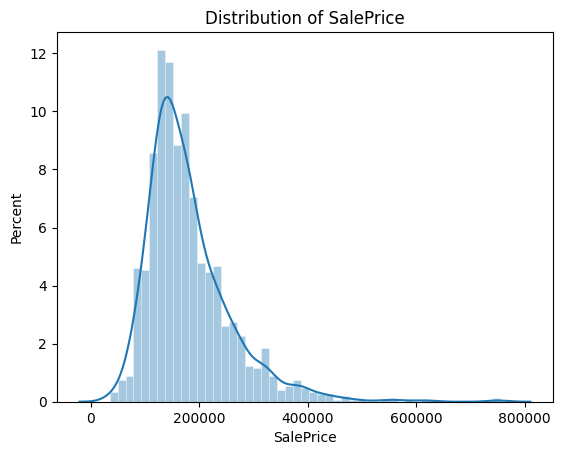

In [145]:
plt.figure()
sns.histplot(
    train.SalePrice, kde=True,
    stat="percent", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4)
)
plt.title('Distribution of SalePrice')
plt.show()

#### Note for Data Cleaning
Adjust and predict for a normal dist SalePrice. Convert back to normal after.

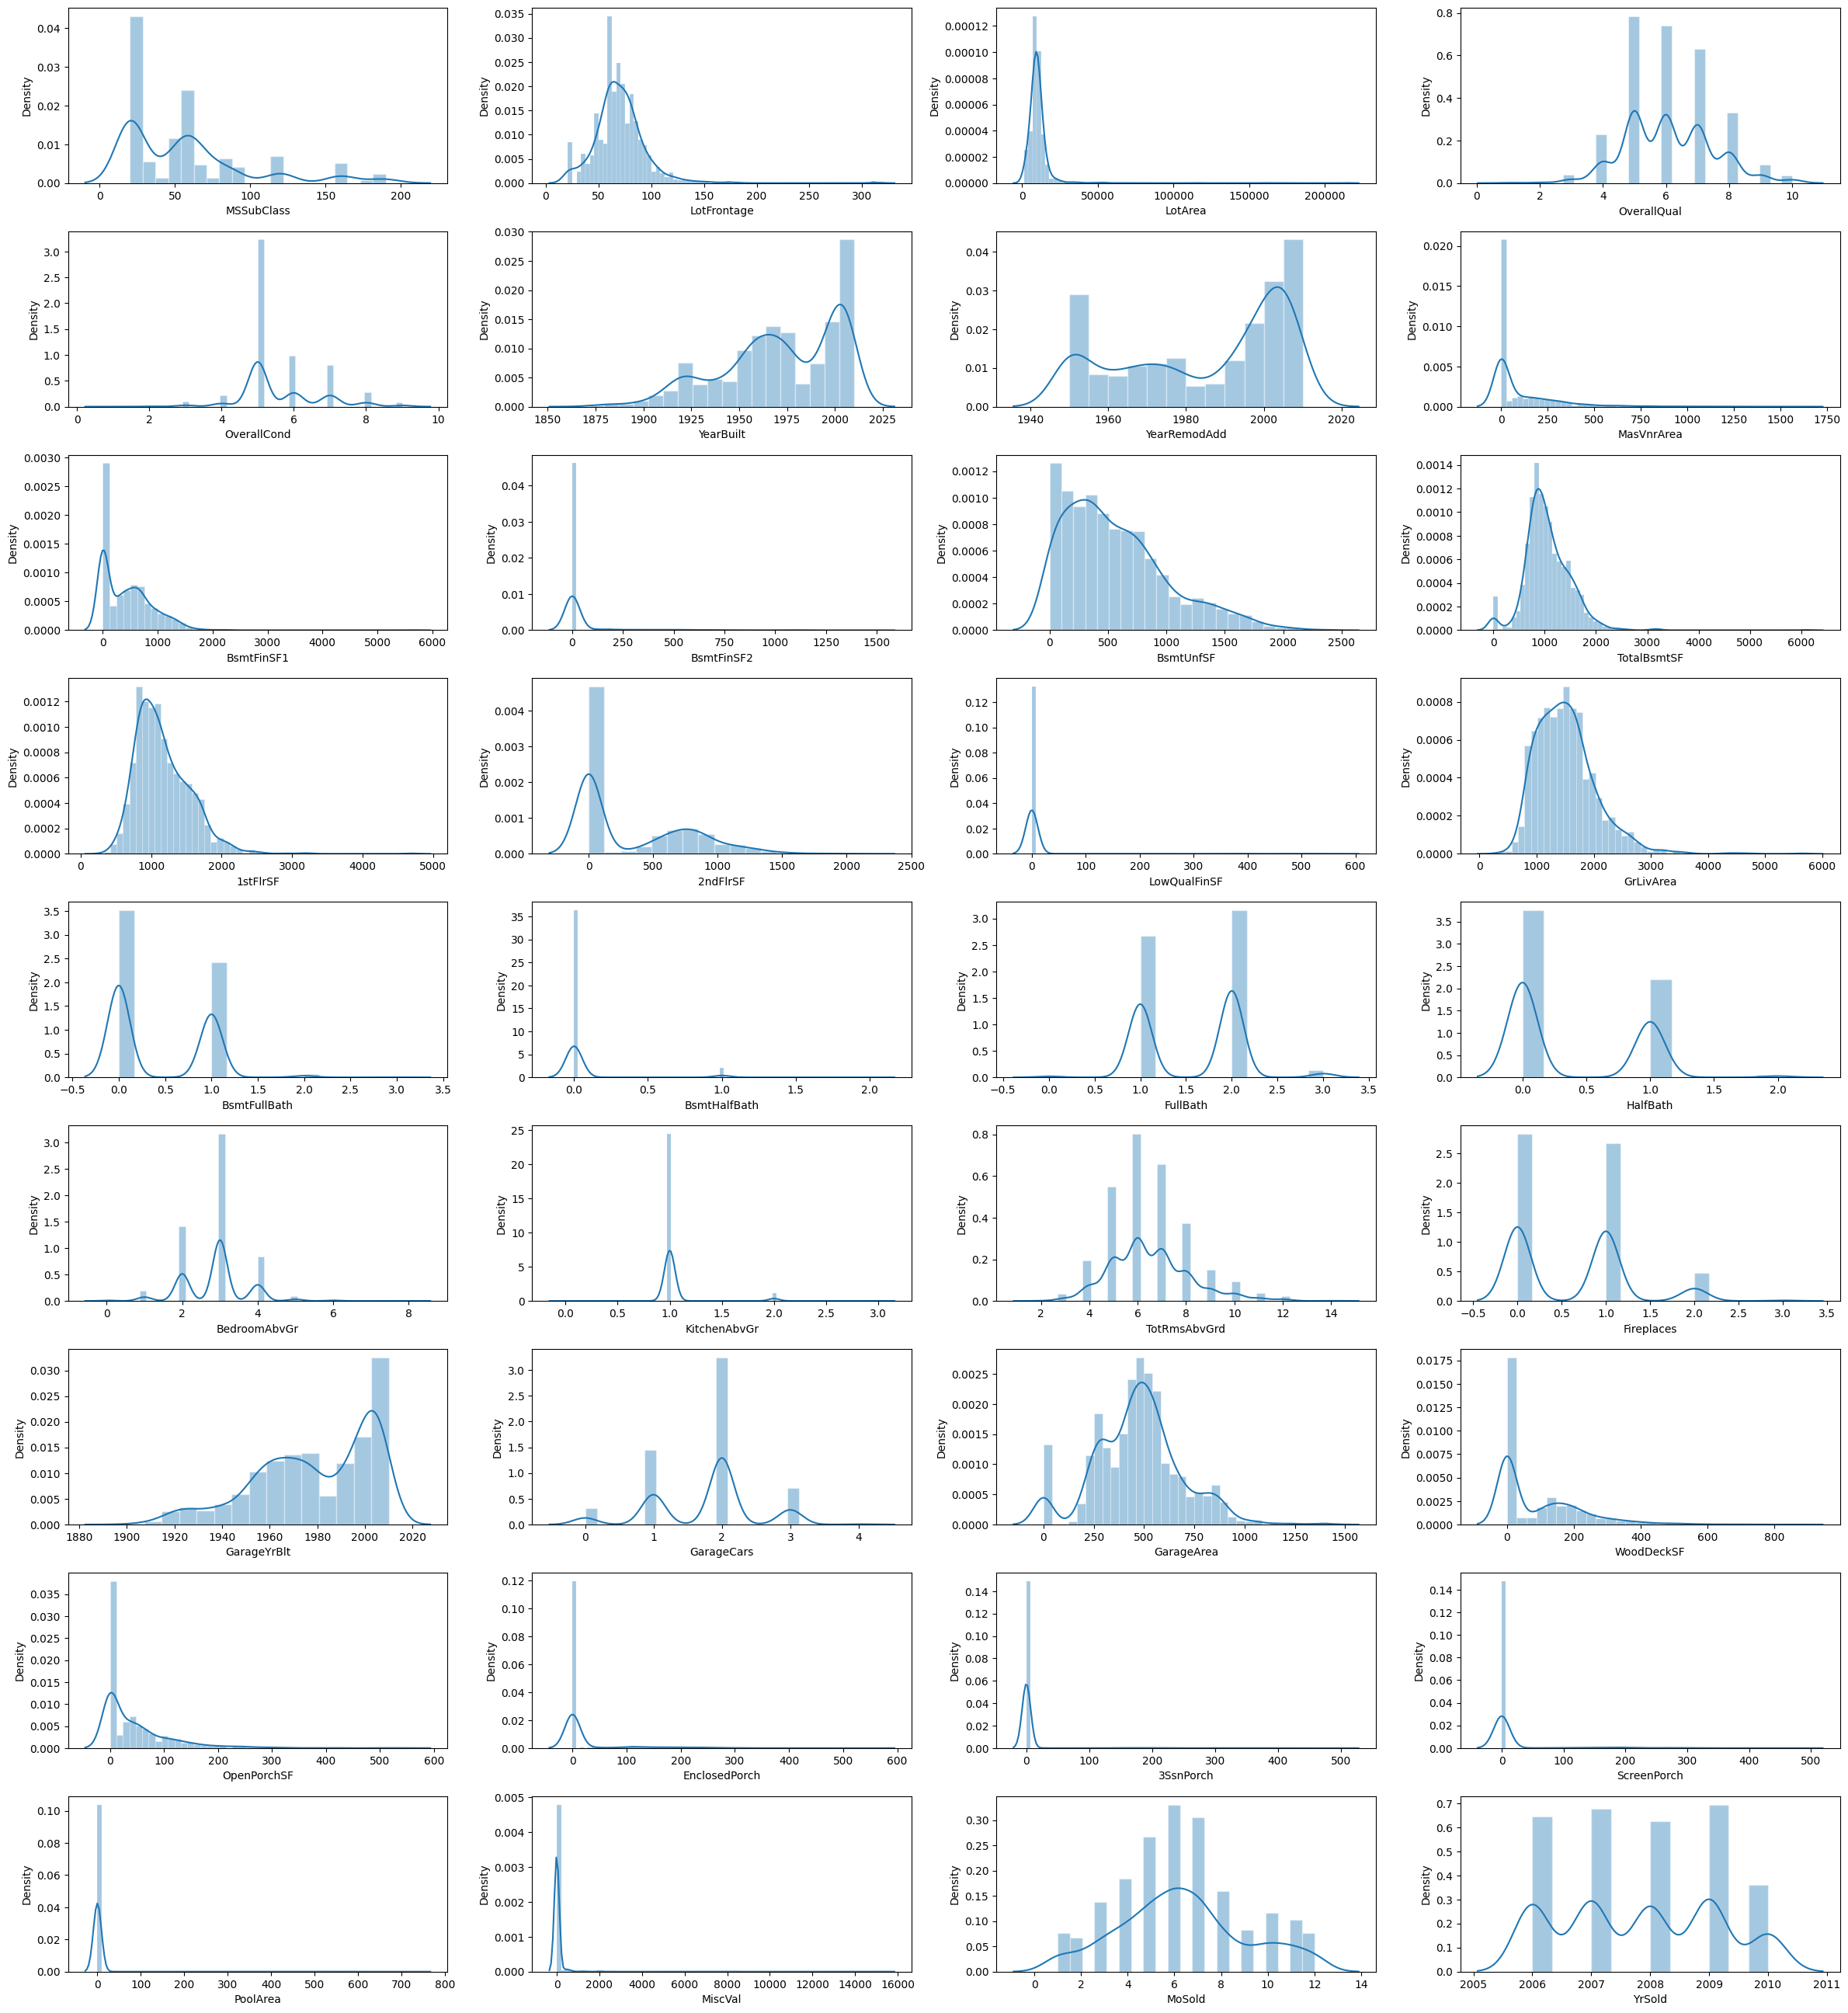

In [146]:
fig = plt.figure(figsize=(24,26))
for i in range(1, 37):
    fig.add_subplot(9,4,i)
    sns.histplot(
    num_features.iloc[:,i].dropna(), kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4)
)
    plt.xlabel(num_features.columns[i])

plt.tight_layout(pad=1.0)

In [147]:
cont_num_var = ['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal']

disc_num_var = list(set(num_features.columns) - set(cont_num_var) - set(['Id', 'SalePrice']))

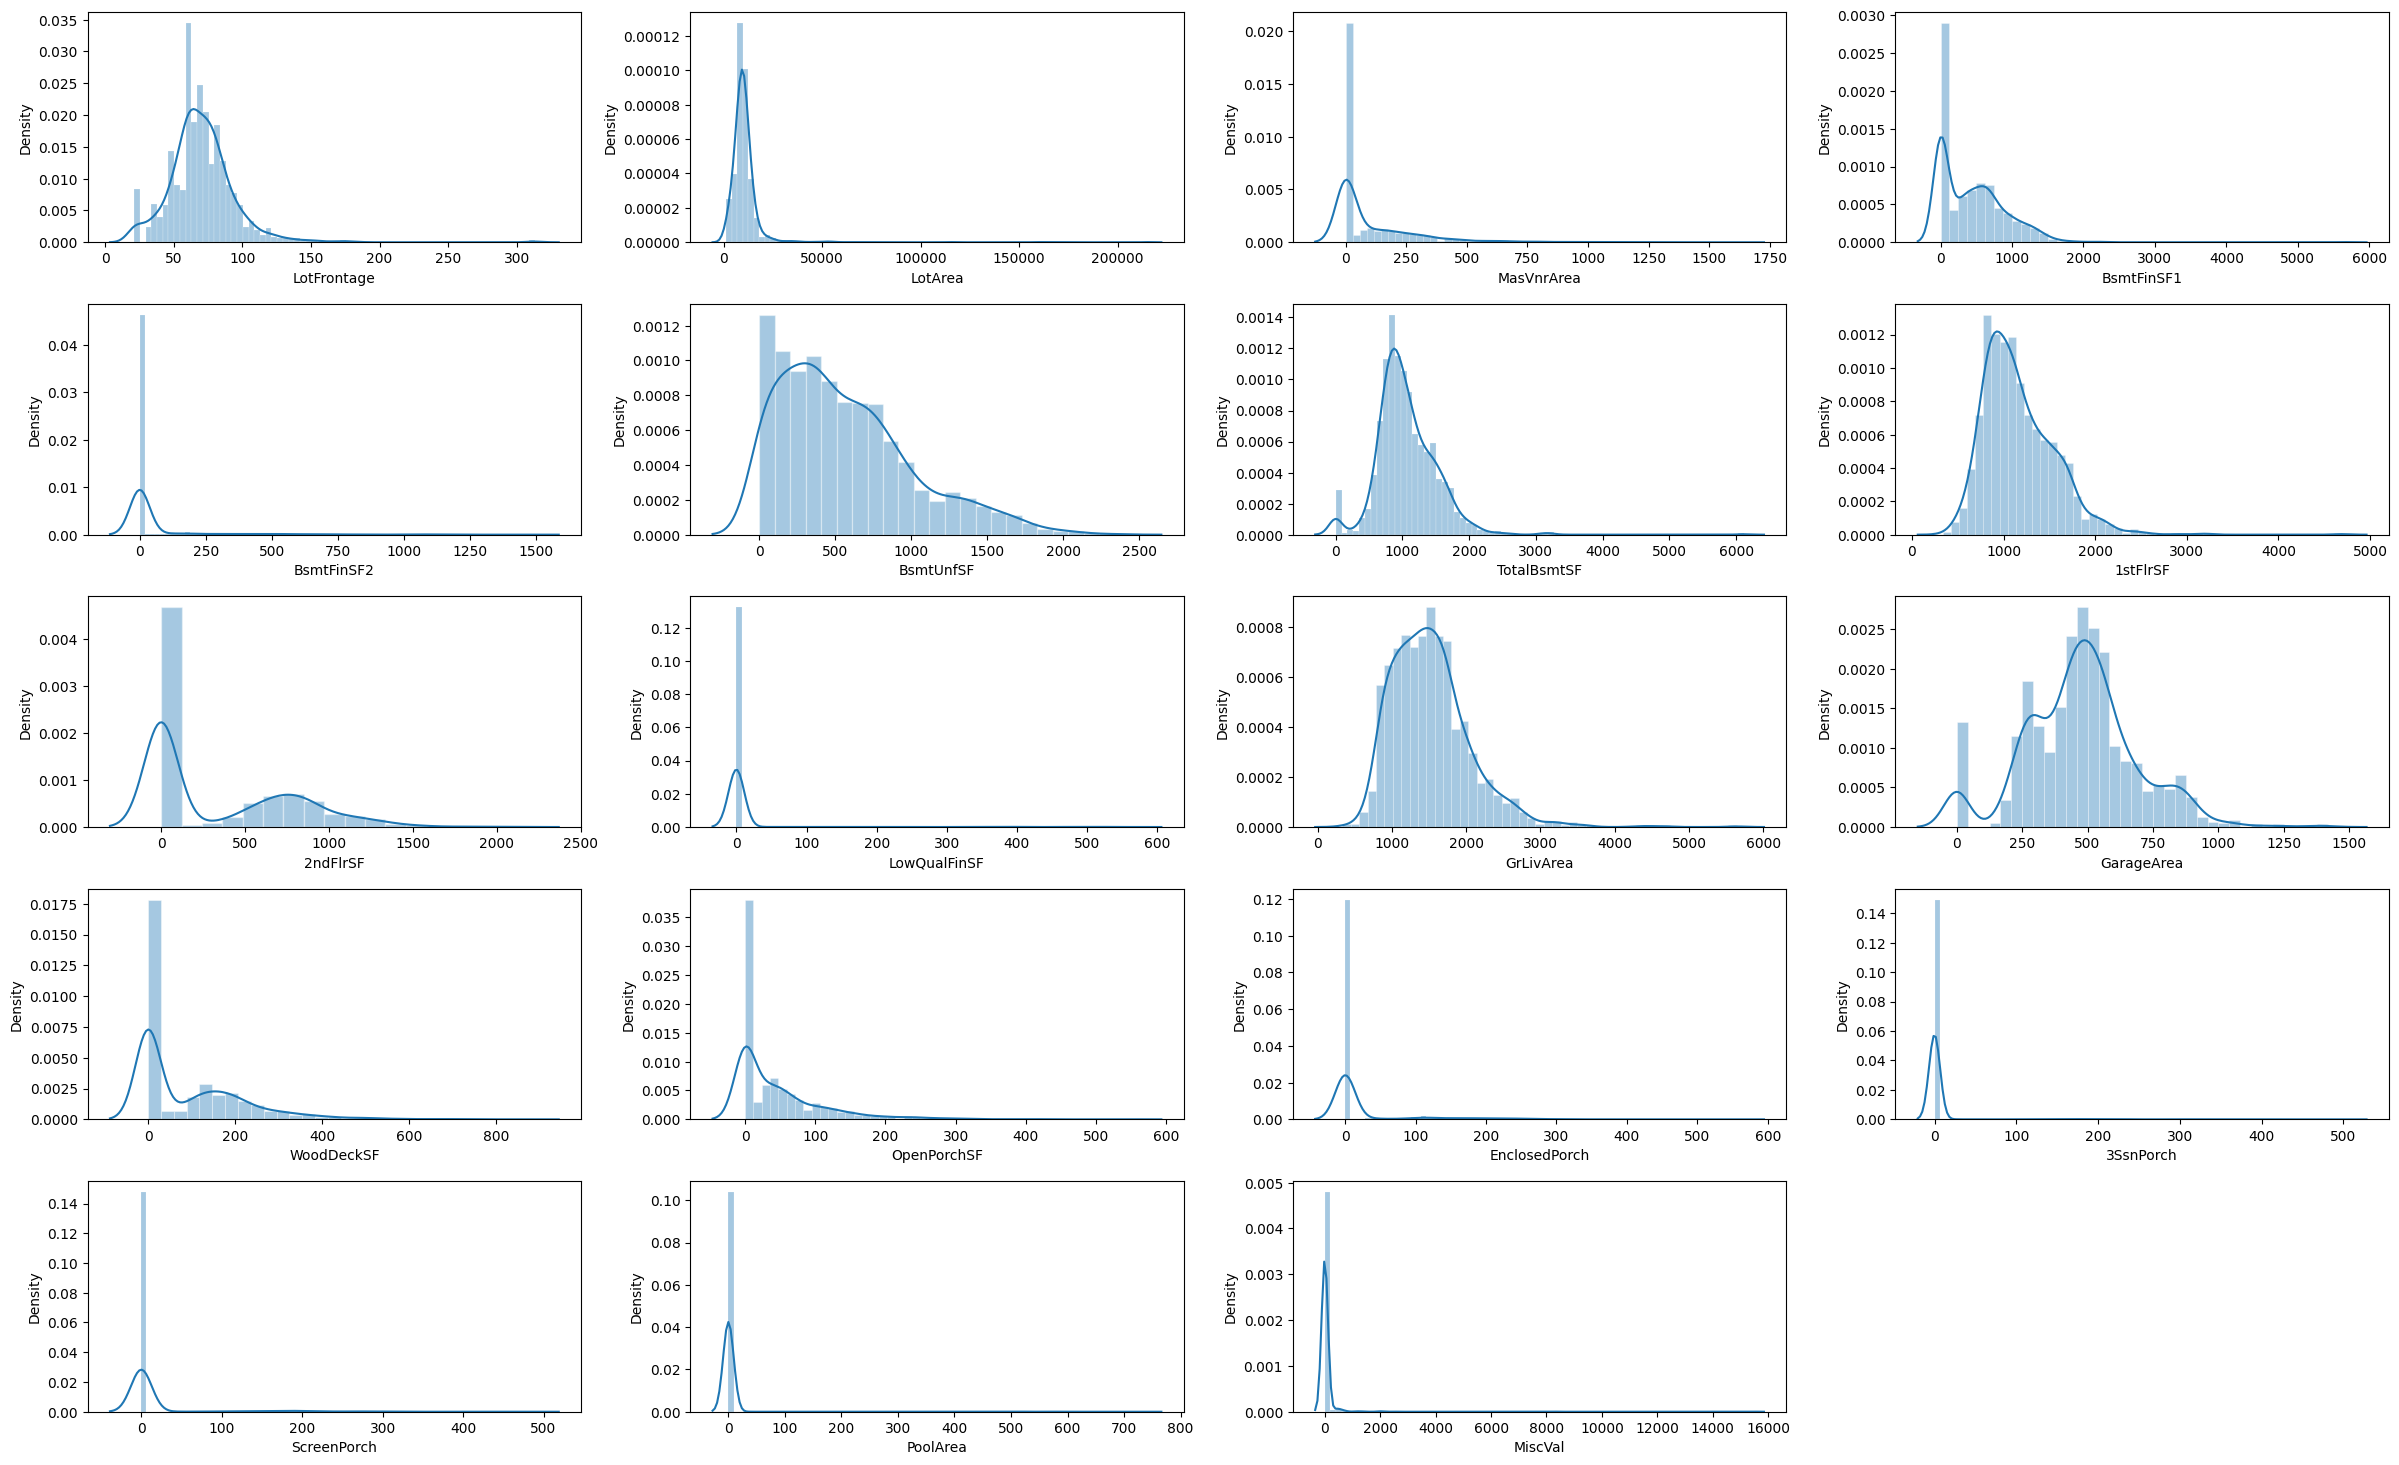

In [148]:
fig = plt.figure(figsize=(24,26))
for i in range(len(cont_num_var)):
    fig.add_subplot(9,4,i+1)
    sns.histplot(
    num_features[cont_num_var].iloc[:,i], kde=True,
    stat="density", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4)
)
    plt.xlabel(num_features[cont_num_var].columns[i])

plt.tight_layout(pad=1.0)

#### Note for Data Cleaning
Adjust and normalize continous numerical features. using log-transform preserves importance of 0

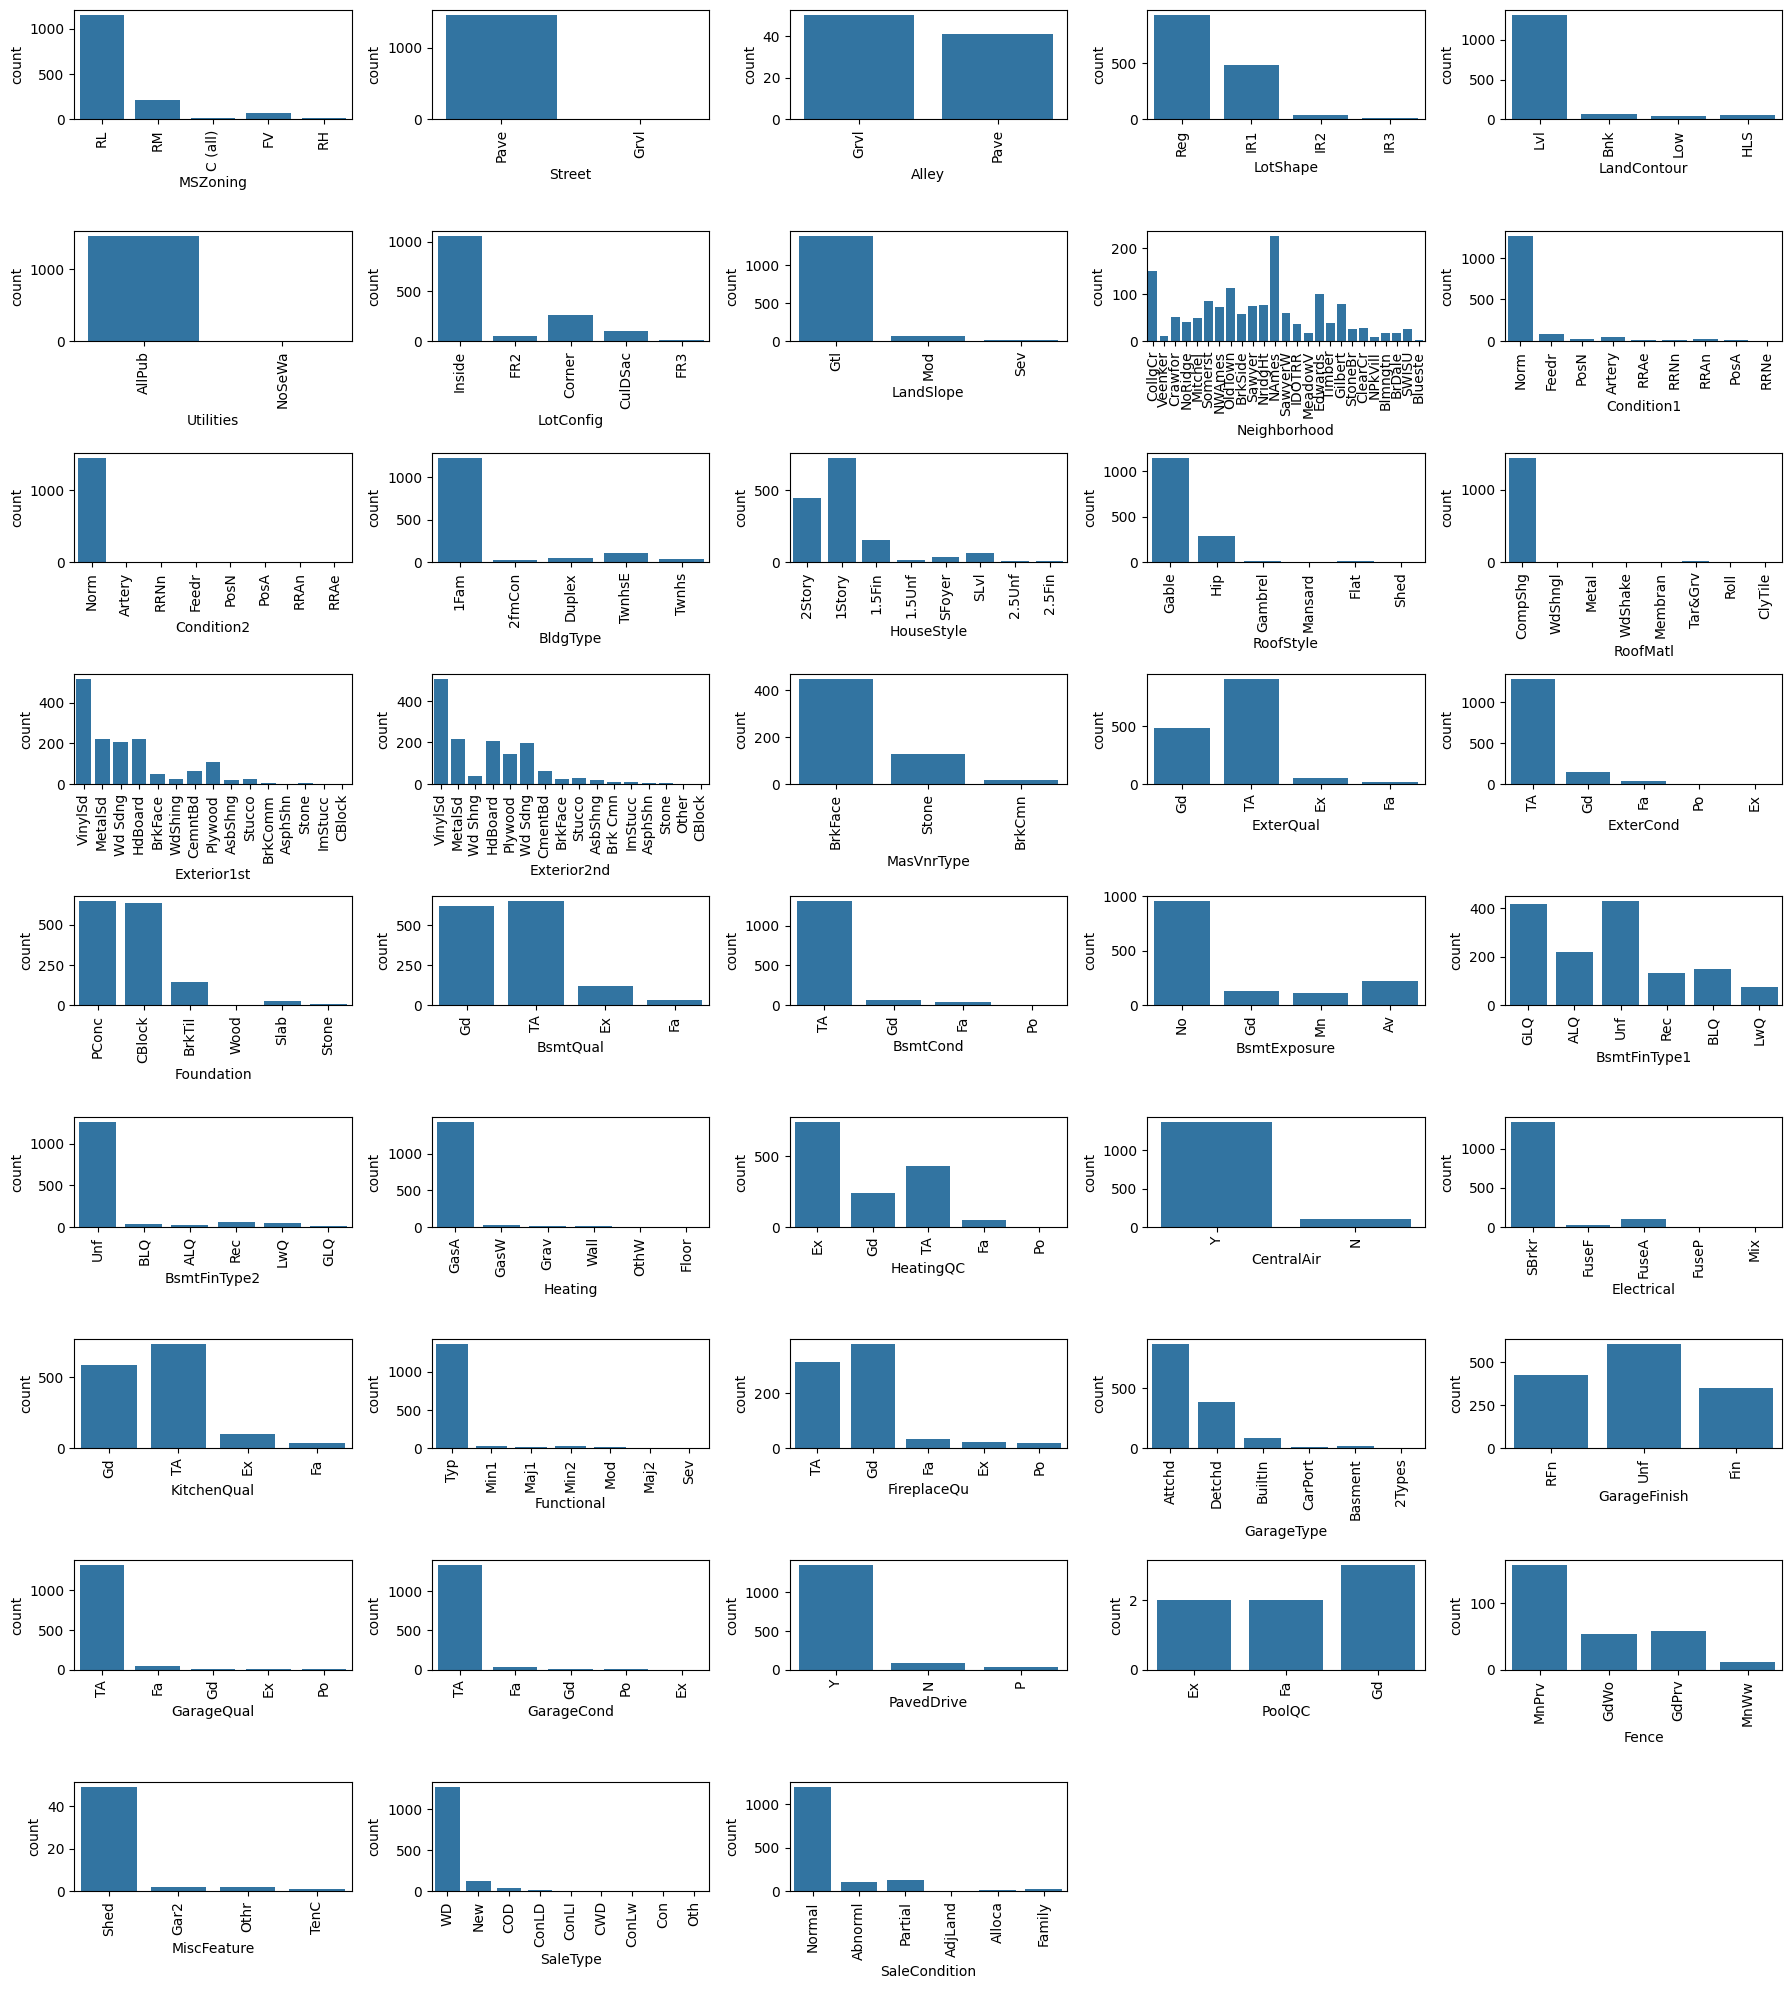

In [149]:
fig = plt.figure(figsize=(18,20))
for index in range(len(cat_features.columns)):
    plt.subplot(9,5,index+1)
    sns.countplot(x=cat_features.iloc[:,index], data=cat_features)
    plt.xticks(rotation=90)
fig.tight_layout(pad=1.0)

## Bivariate Analysis

<Axes: >

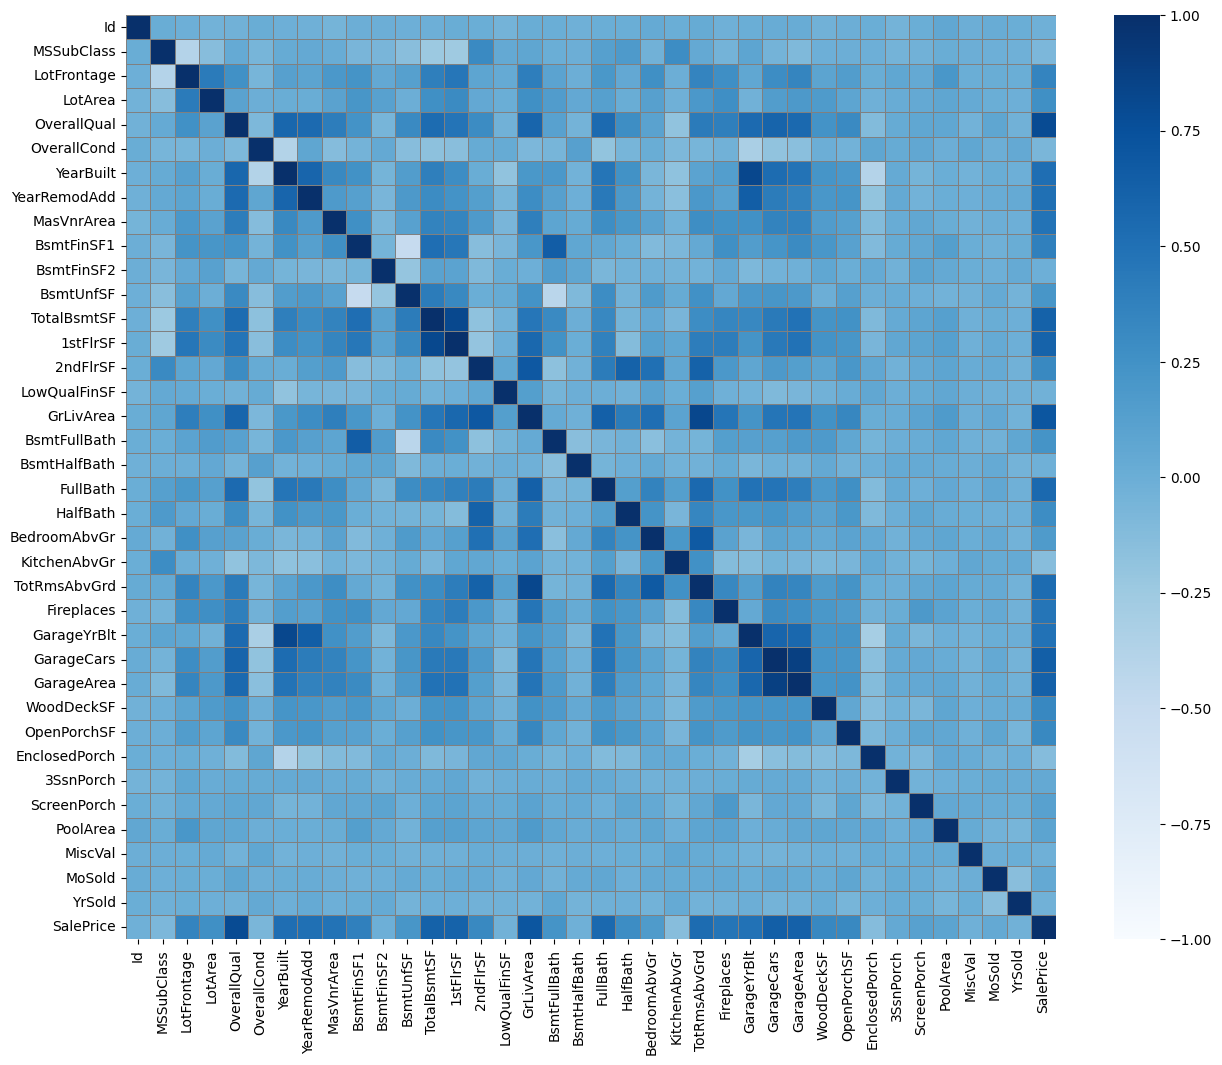

In [150]:
plt.figure(figsize=(15,12))
correlation = num_features.corr()
sns.heatmap(correlation, linewidth=0.5, linecolor="gray", cmap="Blues", vmin=-1, vmax=1)

There are four cases of potential multicolinearity:
- GarageCars vs GarageArea 
- TotalBsmtSF vs 1stFlrSF
- YearBuilt vs GarageYrBlt
- GrLivArea vs TotRmsAbvGrd

This will help us reduce performance issues by removing highly correlated features.

In [151]:
correlation = train.select_dtypes(exclude=['object']).corr()
correlation[['SalePrice']].sort_values(['SalePrice'], ascending=False)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


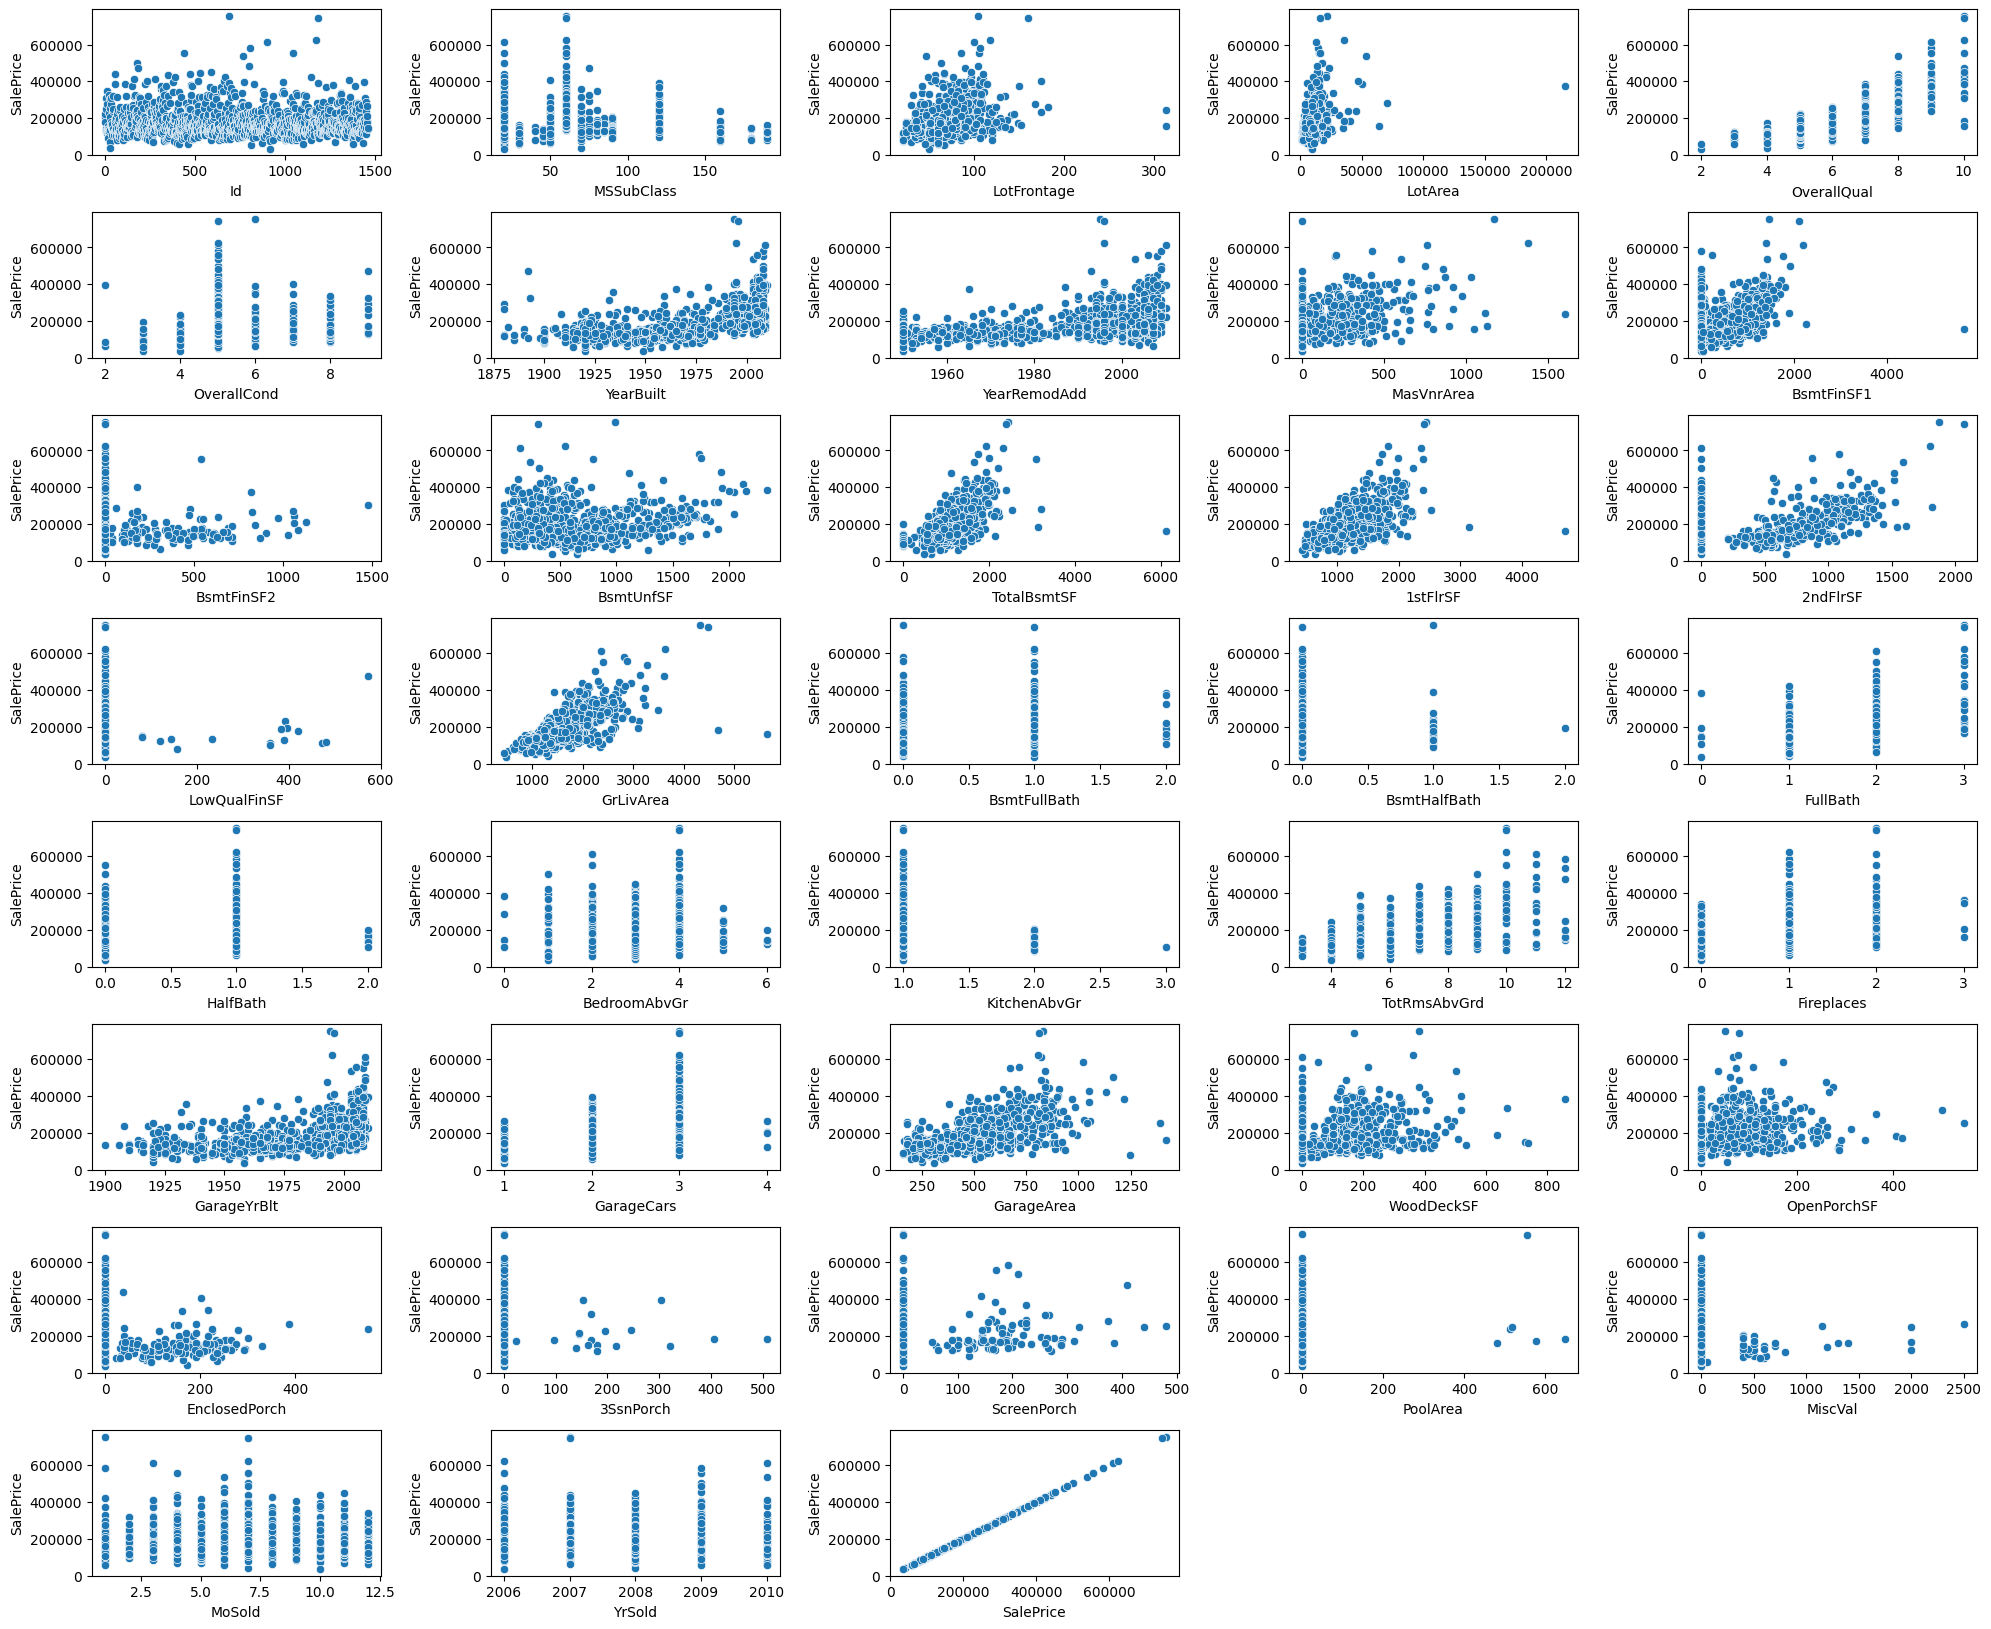

In [152]:
fig = plt.figure(figsize=(20,20))
for index in range(len(num_features.columns)):
    plt.subplot(10,5,index+1)
    sns.scatterplot(x=num_features.iloc[:,index], y='SalePrice', data=num_features.dropna())
fig.tight_layout(pad=1.0)

## 2. Data Cleaning

In [153]:
train_copy = train.copy()
test_copy = test.copy()

## 2.1 Multicolinearity

Removing redundant columns to reduce multicollinearity. I've identified 4 pairs of features that have high correlation with each other from the bivariate analysis section above.
- GarageCars vs GarageArea 
- TotalBsmtSF vs 1stFlrSF
- YearBuilt vs GarageYrBlt
- GrLivArea vs TotRmsAbvGrd



In [154]:
cols = ['GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'YearBuilt', 'GarageYrBlt', 'GrLivArea', 'TotRmsAbvGrd']

# 1. Correlation with SalePrice
corr_with_target = train_copy[cols].corrwith(train_copy['SalePrice'])

# 2. Missing percentage
missing_pct = train_copy[cols].isna().mean() * 100

# 3. Variance
variance_vals = train_copy[cols].var()

feature_stats = pd.DataFrame({
    'correlation_with_SalePrice': corr_with_target,
    'missing_percent': missing_pct,
    'variance': variance_vals
})
feature_stats

,correlation_with_SalePrice,missing_percent,variance
GarageCars,0.640409,0.000000,0.558480
GarageArea,0.623431,0.000000,45712.510229
TotalBsmtSF,0.613581,0.000000,192462.361709
1stFlrSF,0.605852,0.000000,149450.079204
YearBuilt,0.522897,0.000000,912.215413
GarageYrBlt,0.486362,5.547945,609.582509
GrLivArea,0.708624,0.000000,276129.633363
TotRmsAbvGrd,0.533723,0.000000,2.641903


When deciding what features to remove, the idea is to keep features that will help better the prediction accuracy. This mean giving more info and we can discern that through the feature's correlation, missing percent, and variance. Higher correlation, lower missing values, and higher variance are good.

The feature statistics above will help decide which features to remove:
- GarageCars vs GarageArea: Keep GarageArea -> Although it has slightly lower correlation with SalePrice, it has much high variance as a continuous variable, which may result in better predictions.
- TotalBsmtSF vs 1stFlrSF: Keep 1stFlrSF -> Although stats are similar, it makes better sense contextually to keep the 1st floor area than the basement area as house buyers will prioritize first floor area more than basement.
- YearBuilt vs GarageYrBlt: Keep YearBlt -> Higher correlation, less missing values, higher variance, better context.
- GrLivArea vs TotRmsAbvGrd: Keep GrLivArea -> Higher correlation, higher variance.

In [155]:
train_copy.drop(['GarageCars', 'TotalBsmtSF', 'GarageYrBlt', 'TotRmsAbvGrd'], axis=1, inplace=True)
test_copy.drop(['GarageCars', 'TotalBsmtSF', 'GarageYrBlt', 'TotRmsAbvGrd'], axis=1, inplace=True)

## 2.2 Missing values

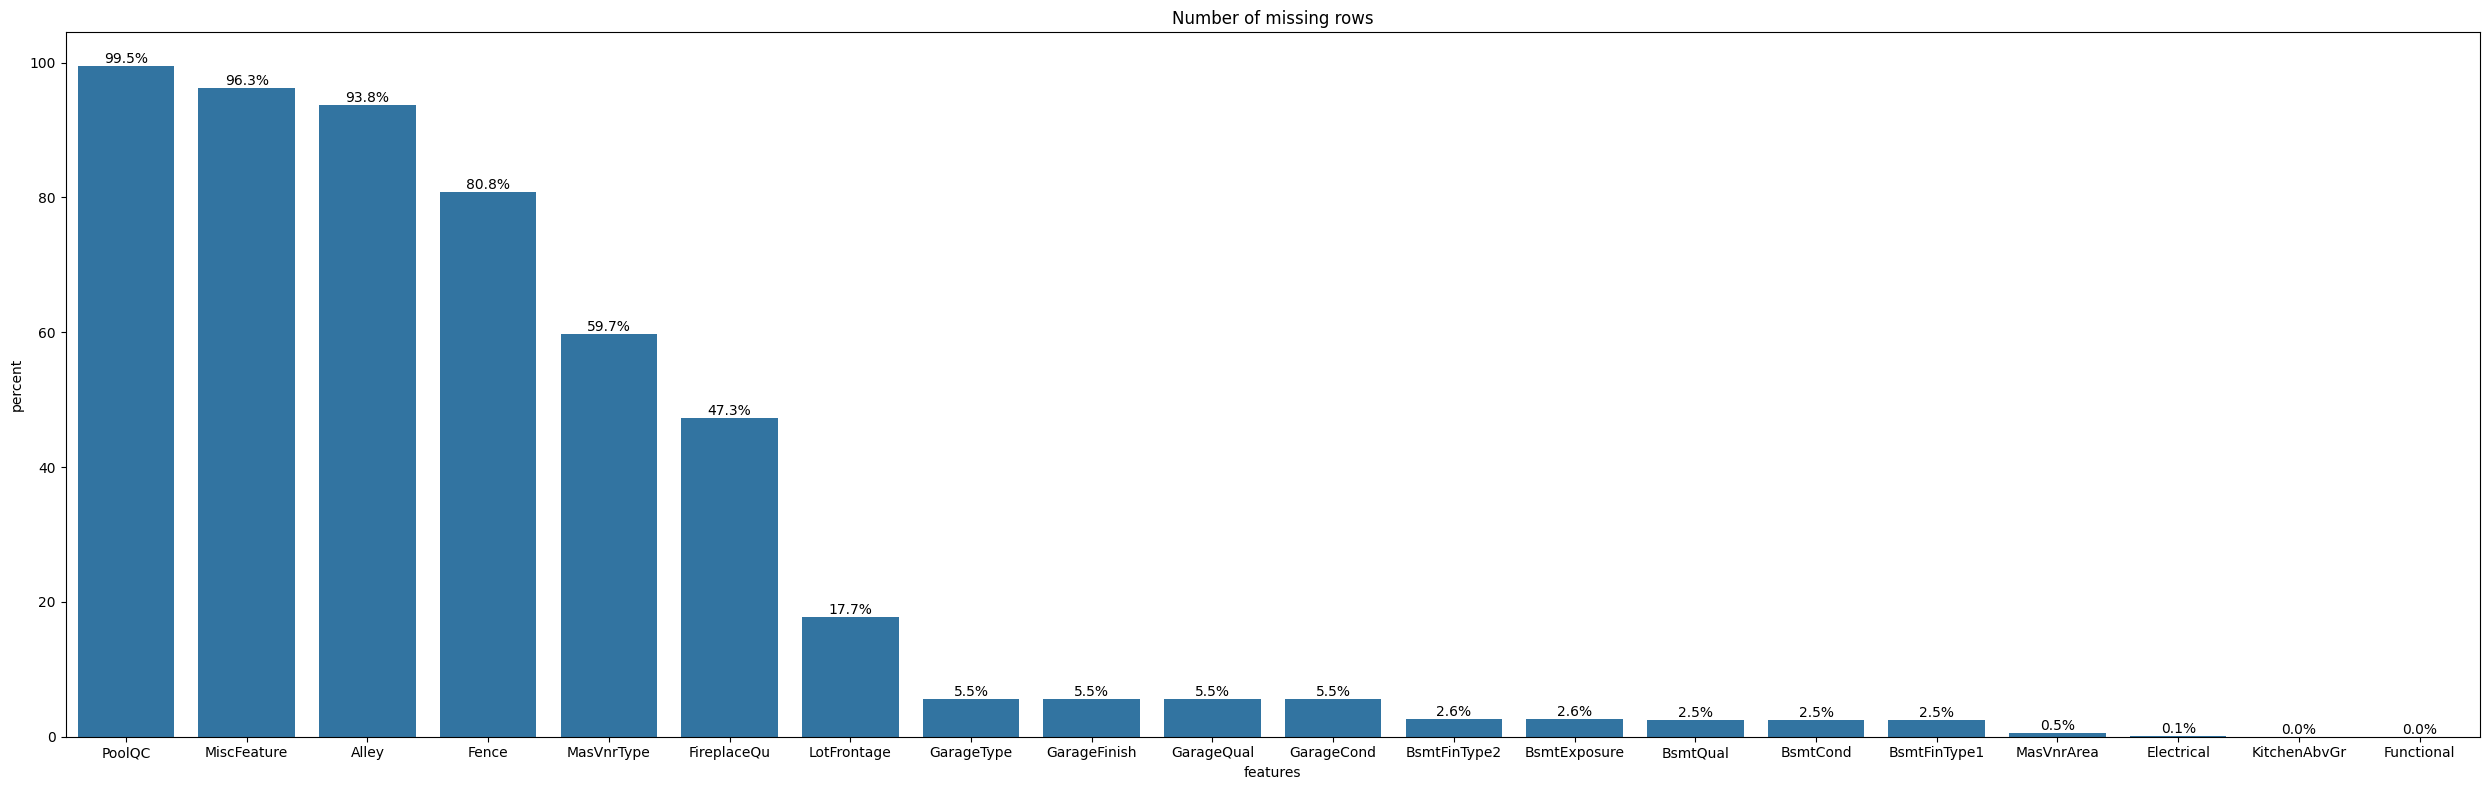

In [156]:
plt.figure(figsize=(25,8))
plt.title('Number of missing rows')
missing_count = pd.DataFrame(train_copy.isnull().mean()*100, columns=['sum']).sort_values(by=['sum'],ascending=False).head(20).reset_index()
missing_count.columns = ['features','percent']
ax = sns.barplot(x='features',y='percent', data = missing_count)

ax.bar_label(ax.containers[0], fmt="%.1f%%")

plt.tight_layout()
plt.show()

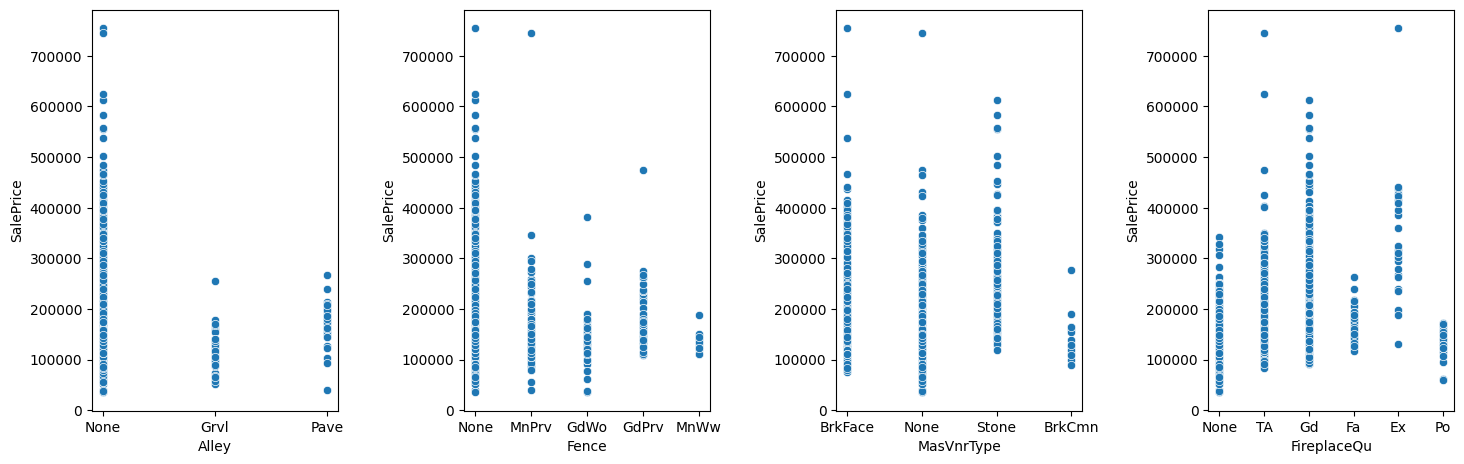

In [157]:
fig,axes = plt.subplots(1,4, figsize=(15,5))
tmp = train_copy[['SalePrice', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu']].fillna("None")
sns.scatterplot(x=tmp['Alley'], y='SalePrice', data=tmp, ax = axes[0])
sns.scatterplot(x=tmp['Fence'], y='SalePrice', data=tmp, ax = axes[1])
sns.scatterplot(x=tmp['MasVnrType'], y='SalePrice', data=tmp, ax = axes[2])
sns.scatterplot(x=tmp['FireplaceQu'], y='SalePrice', data=tmp, ax = axes[3])
fig.tight_layout(pad=2.0)


First I'll take a look at the feature with high amounts of missing values and decide if I can remove them. 

PoolQC - Indicates the quality of the pool, with missing values meaning no pool. There is a related feature called PoolArea that denotes the size of the pool, with 0 being no pool. Instinctually, a pool would increase the value of a house, but looking at the correlation analysis above, there does not seem to be a significant relationship between PoolArea (0.09) -> will remove PoolQC. Just keeping PoolArea will incorporate any benefits to SalePrice a pool could bring.

MiscFeature - Same logic, I'll just keep MiscVal to incorporate any correlation.

Alley - As a standalone feature, I'll take a closer look at the scatterplot for any relationship. There does not seem to be a significant relationship between SalePrice and the existence of an alley, therefore will remove feature.

Fence - The only feature that provide information regarding fences, will keep and fill missing with "None"

MasVnrType - The related MaxVnrArea feature seems to show a positive relationship with SalePrice, will keep this feature and fill missing values with "None". This feature also doesn't have extreme amounts of missing values (>90%)

FireplaceQu - The related Fireplaces feature seems to show a positive relationship with SalePrice, will keep this feature and fill missing values with "None". This feature also doesn't have extreme amounts of missing values (>90%)



In [158]:
train_copy.drop(['PoolQC', 'MiscFeature', 'Alley'], axis=1, inplace=True)
train_copy[['Fence', 'MasVnrType', 'FireplaceQu']] = train_copy[['Fence', 'MasVnrType', 'FireplaceQu']].fillna("None")

test_copy.drop(['PoolQC', 'MiscFeature', 'Alley'], axis=1, inplace=True)
test_copy[['Fence', 'MasVnrType', 'FireplaceQu']] = train_copy[['Fence', 'MasVnrType', 'FireplaceQu']].fillna("None")

GarageType / GarageFinish / GarageQual / GarageCond
Missing values for the above signify no garage -> fill with "None"

BsmtQual / BsmtCond / BsmtExposure / BsmtFinType1 / BsmtFinType2
Missing values for the above signify no garage -> fill with "None"

Electrical - Populate electrical type with the most common electrical system SBrkr

MasVnrArea - Populate with average based on MaxVnrType

LotFrontage - Doesn't seem to be related to other features heavily, will populate missing values with median value


In [159]:
cols = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
train_copy[cols] = train_copy[cols].fillna("None")
test_copy[cols] = test_copy[cols].fillna("None")

train_copy[['Electrical']] = train_copy[['Electrical']].fillna("Sbrkr")
test_copy[['Electrical']] = test_copy[['Electrical']].fillna("Sbrkr")

train_copy['MasVnrArea'] = (
    train_copy.groupby('MasVnrType')['MasVnrArea']
              .transform(lambda x: x.fillna(x.mean()))
)
test_copy['MasVnrArea'] = (
    test_copy.groupby('MasVnrType')['MasVnrArea']
              .transform(lambda x: x.fillna(x.mean()))
)

train_copy['LotFrontage'] = train_copy['LotFrontage'].fillna(train_copy['LotFrontage'].median())
test_copy['LotFrontage'] = test_copy['LotFrontage'].fillna(test_copy['LotFrontage'].median())

In [160]:
print(f"Any missing values: {train_copy.isna().any().any()}")
print(f"Number of missing values: {train_copy.isna().sum().sum()}")

Any missing values: False
Number of missing values: 0


In [161]:
print(f"Any missing values: {test_copy.isna().any().any()}")
print(f"Number of missing values: {test_copy.isna().sum().sum()}")

Any missing values: True
Number of missing values: 20


In [162]:
# # Show amount of missing values

# plt.figure(figsize=(25,8))
# plt.title('Number of missing rows')
# missing_count = pd.DataFrame(train_copy.isnull().mean()*100, columns=['sum']).sort_values(by=['sum'],ascending=False).head(20).reset_index()
# missing_count.columns = ['features','percent']
# ax = sns.barplot(x='features',y='percent', data = missing_count)

# ax.bar_label(ax.containers[0], fmt="%.1f%%")

# plt.tight_layout()
# plt.show()

## 2.3 Outliers

Taking a look at the distributions for the continuous numerical features we can see that most of the features are non-normally distributed. I will log-transform these features to normalize the values, hopefully inproving prediction accuracy. 

I'm choosing to log-transform because of the simplicity, but also a log transformation handles zero data (which has importance in these features signifying non-existant) and positively skewed data (which all the features are).

In [163]:
cont_num_var = ['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal']

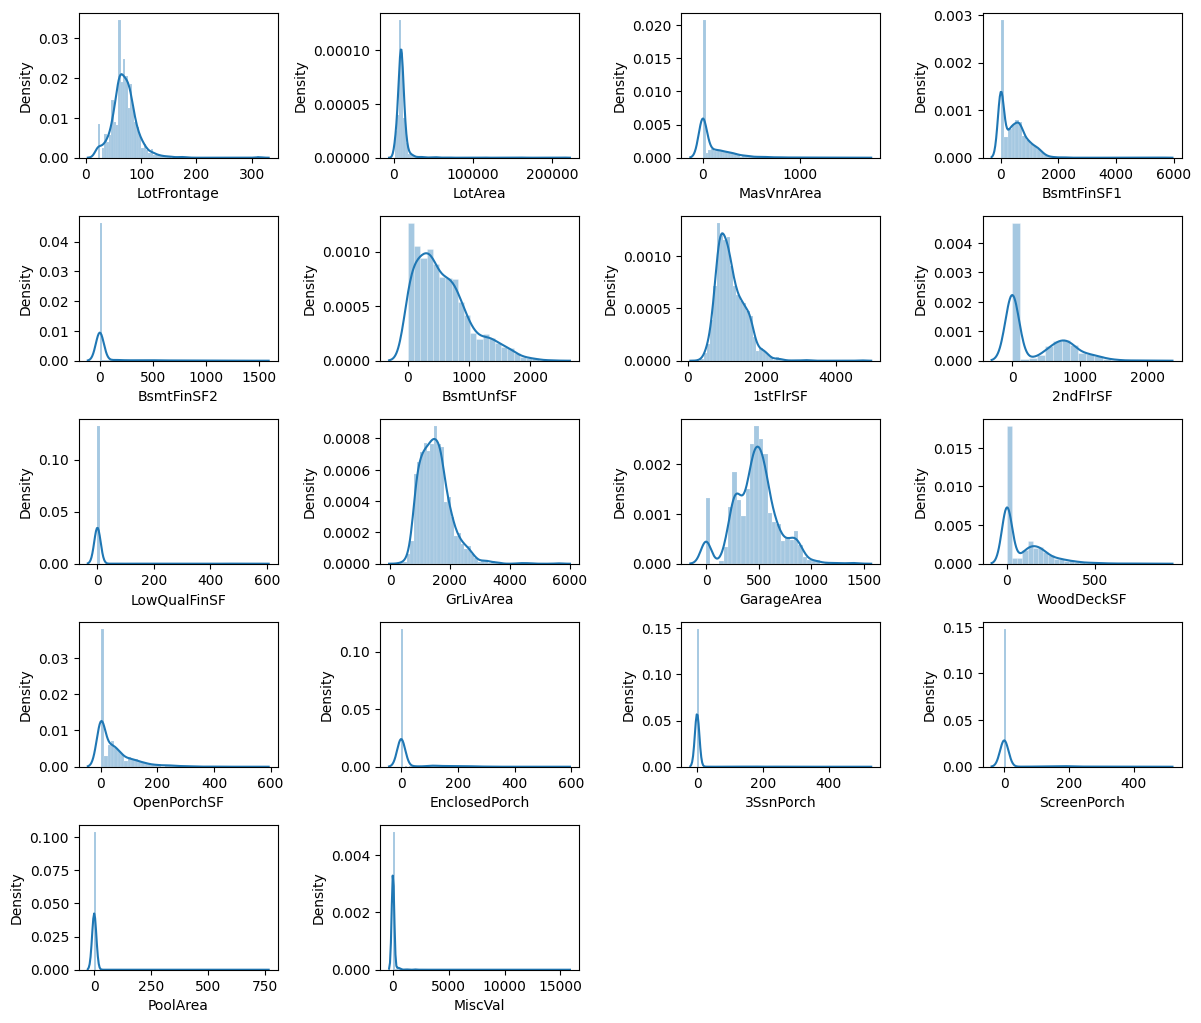

In [164]:
fig = plt.figure(figsize=(12, 18))

for i, col in enumerate(cont_num_var):
    if col in train.columns:
        fig.add_subplot(9, 4, i + 1)
        sns.histplot(
            train[col].dropna(), kde=True,
            stat="density", kde_kws=dict(cut=3),
            alpha=.4, edgecolor=(1, 1, 1, .4)
        )
        plt.xlabel(col)

plt.tight_layout(pad=1.0)

In [165]:
train_copy[cont_num_var].skew()
# train_copy[[c + '_log' for c in cols]].skew()

LotFrontage       2.409147
LotArea          12.207688
MasVnrArea        2.677700
BsmtFinSF1        1.685503
BsmtFinSF2        4.255261
BsmtUnfSF         0.920268
1stFlrSF          1.376757
2ndFlrSF          0.813030
LowQualFinSF      9.011341
GrLivArea         1.366560
GarageArea        0.179981
WoodDeckSF        1.541376
OpenPorchSF       2.364342
EnclosedPorch     3.089872
3SsnPorch        10.304342
ScreenPorch       4.122214
PoolArea         14.828374
MiscVal          24.476794
dtype: float64

In [166]:
for col in cont_num_var:
    train_copy[col] = np.log1p(train_copy[col])

for col in cont_num_var:
    test_copy[col] = np.log1p(test_copy[col])    

In [167]:
train_copy[cont_num_var].skew()

LotFrontage      -0.870006
LotArea          -0.137404
MasVnrArea        0.502545
BsmtFinSF1       -0.618410
BsmtFinSF2        2.523694
BsmtUnfSF        -2.186504
1stFlrSF          0.080114
2ndFlrSF          0.289643
LowQualFinSF      7.460317
GrLivArea        -0.006140
GarageArea       -3.482604
WoodDeckSF        0.153537
OpenPorchSF      -0.023397
EnclosedPorch     2.112275
3SsnPorch         7.734975
ScreenPorch       3.150409
PoolArea         14.363102
MiscVal           5.170704
dtype: float64

# 3. Feature Engineering

Getting numerical dummies for non-numeric features.

In [193]:
train_dum = pd.get_dummies(
    train_copy,
    columns=train_copy.select_dtypes(include='object').columns,
    drop_first=True
)

test_dum = pd.get_dummies(
    test_copy,
    columns=test_copy.select_dtypes(include='object').columns,
    drop_first=True
)

# Align test to train
train_final, test_final = train_dum.align(test_dum, join='left', axis=1, fill_value=0)
test_final.drop(['SalePrice'], axis=1, inplace=True)

train_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 249 entries, Id to SaleCondition_Partial
dtypes: bool(215), float64(18), int64(16)
memory usage: 694.5 KB


In [194]:
test_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Columns: 248 entries, Id to SaleCondition_Partial
dtypes: bool(198), float64(20), int64(30)
memory usage: 852.2 KB


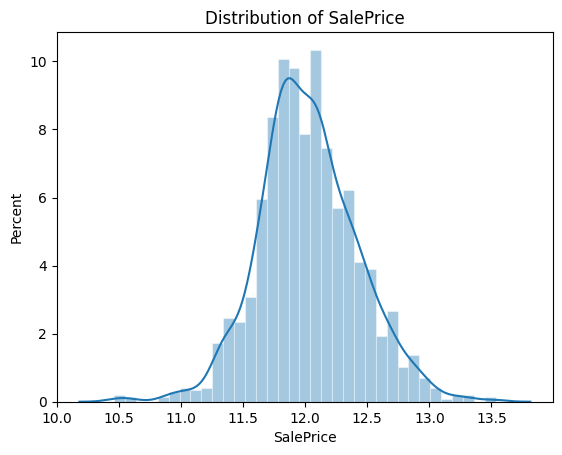

In [195]:
train_final['SalePrice'] = np.log(train_copy['SalePrice'])

plt.figure()
sns.histplot(
    train_final.SalePrice, kde=True,
    stat="percent", kde_kws=dict(cut=3),
    alpha=.4, edgecolor=(1, 1, 1, .4)
)
plt.title('Distribution of SalePrice')
plt.show()

In [196]:
# X = train_copy.copy().dropna()
# y = X.pop('SalePrice')

# X.head(10)

# features_num = X.select_dtypes(exclude='object').columns()
# features_cat = X.select_dtypes(include='object').columns()

# preprocessor = make_column_transformer(
#     (StandardScaler(), features_num),
#     (OneHotEncoder(), features_cat),
# )

# X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state = 1)


In [221]:
# X = train_final.drop(['SalePrice'], axis=1)
# y = train_final.SalePrice

# # Split into validation and training data
# train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)

#--------

train_X = train_final.drop(['SalePrice'], axis=1)
train_y = train_final.SalePrice

In [222]:
def inv_y(transformed_y):
    return np.exp(transformed_y)

# Series to collate mean absolute errors for each algorithm
# mae_compare = pd.Series()
# mae_compare.index.name = 'Algorithm'

# Specify Model ================================
# iowa_model = DecisionTreeRegressor(random_state=1)
# # Fit Model
# iowa_model.fit(train_X, train_y)

# # Make validation predictions and calculate mean absolute error
# val_predictions = iowa_model.predict(val_X)
# val_mae = mean_absolute_error(inv_y(val_predictions), inv_y(val_y))
# mae_compare['DecisionTree'] = val_mae
# # print("Validation MAE for Decision Tree when not specifying max_leaf_nodes: {:,.0f}".format(val_mae))

# Decision Tree. Using best value for max_leaf_nodes ==============
# iowa_model = DecisionTreeRegressor(max_leaf_nodes=90, random_state=1)
# iowa_model.fit(train_X, train_y)
# val_predictions = iowa_model.predict(val_X)
# val_mae = mean_absolute_error(inv_y(val_predictions), inv_y(val_y))
# mae_compare['DecisionTree_opt_max_leaf_nodes'] = val_mae
# # print("Validation MAE for Decision Tree with best value of max_leaf_nodes: {:,.0f}".format(val_mae))

# Random Forest. Define the model. =============================
rf_model = RandomForestRegressor(random_state=5)
rf_model.fit(train_X, train_y)
# rf_val_predictions = rf_model.predict(val_X)
# rf_val_mae = mean_absolute_error(inv_y(rf_val_predictions), inv_y(val_y))

# # mae_compare['RandomForest'] = rf_val_mae
# print("Validation MAE for Random Forest Model: {:,.0f}".format(rf_val_mae))
# print("ok")


# # XGBoost. Define the model. ======================================
# # xgb_model = XGBRegressor(n_estimators=1000, learning_rate=0.05)
# # xgb_model.fit(train_X, train_y, early_stopping_rounds=5, 
# #               eval_set=[(val_X,val_y)], verbose=False)
# # xgb_val_predictions = xgb_model.predict(val_X)
# # xgb_val_mae = mean_absolute_error(inv_y(xgb_val_predictions), inv_y(val_y))

# # mae_compare['XGBoost'] = xgb_val_mae
# # print("Validation MAE for XGBoost Model: {:,.0f}".format(xgb_val_mae))

# # Linear Regression =================================================
# linear_model = LinearRegression()
# linear_model.fit(train_X, train_y)
# linear_val_predictions = linear_model.predict(val_X)
# linear_val_mae = mean_absolute_error(inv_y(linear_val_predictions), inv_y(val_y))

# mae_compare['LinearRegression'] = linear_val_mae
# # print("Validation MAE for Linear Regression Model: {:,.0f}".format(linear_val_mae))

# # Lasso ==============================================================
# lasso_model = Lasso(alpha=0.0005, random_state=5)
# lasso_model.fit(train_X, train_y)
# lasso_val_predictions = lasso_model.predict(val_X)
# lasso_val_mae = mean_absolute_error(inv_y(lasso_val_predictions), inv_y(val_y))

# mae_compare['Lasso'] = lasso_val_mae
# # print("Validation MAE for Lasso Model: {:,.0f}".format(lasso_val_mae))

# # Ridge ===============================================================
# ridge_model = Ridge(alpha=0.002, random_state=5)
# ridge_model.fit(train_X, train_y)
# ridge_val_predictions = ridge_model.predict(val_X)
# ridge_val_mae = mean_absolute_error(inv_y(ridge_val_predictions), inv_y(val_y))

# mae_compare['Ridge'] = ridge_val_mae
# # print("Validation MAE for Ridge Regression Model: {:,.0f}".format(ridge_val_mae))

# # ElasticNet ===========================================================
# elastic_net_model = ElasticNet(alpha=0.02, random_state=5, l1_ratio=0.7)
# elastic_net_model.fit(train_X, train_y)
# elastic_net_val_predictions = elastic_net_model.predict(val_X)
# elastic_net_val_mae = mean_absolute_error(inv_y(elastic_net_val_predictions), inv_y(val_y))

# mae_compare['ElasticNet'] = elastic_net_val_mae
# # print("Validation MAE for Elastic Net Model: {:,.0f}".format(elastic_net_val_mae))

# # KNN Regression ========================================================
# # knn_model = KNeighborsRegressor()
# # knn_model.fit(train_X, train_y)
# # knn_val_predictions = knn_model.predict(val_X)
# # knn_val_mae = mean_absolute_error(inv_y(knn_val_predictions), inv_y(val_y))

# # mae_compare['KNN'] = knn_val_mae
# # # print("Validation MAE for KNN Model: {:,.0f}".format(knn_val_mae))

# # Gradient Boosting Regression ==========================================
# gbr_model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, 
#                                       max_depth=4, random_state=5)
# gbr_model.fit(train_X, train_y)
# gbr_val_predictions = gbr_model.predict(val_X)
# gbr_val_mae = mean_absolute_error(inv_y(gbr_val_predictions), inv_y(val_y))

# mae_compare['GradientBoosting'] = gbr_val_mae
# # print("Validation MAE for Gradient Boosting Model: {:,.0f}".format(gbr_val_mae))

# # # Ada Boost Regression ================================================
# # ada_model = AdaBoostRegressor(n_estimators=300, learning_rate=0.05, random_state=5)
# # ada_model.fit(train_X, train_y)
# # ada_val_predictions = ada_model.predict(val_X)
# # ada_val_mae = mean_absolute_error(inv_y(ada_val_predictions), inv_y(val_y))

# # mae_compare['AdaBoost'] = ada_val_mae
# # # print("Validation MAE for Ada Boost Model: {:,.0f}".format(ada_val_mae))

# # # Support Vector Regression ===========================================
# # svr_model = SVR(kernel='linear')
# # svr_model.fit(train_X, train_y)
# # svr_val_predictions = svr_model.predict(val_X)
# # svr_val_mae = mean_absolute_error(inv_y(svr_val_predictions), inv_y(val_y))

# # mae_compare['SVR'] = svr_val_mae
# # print("Validation MAE for SVR Model: {:,.0f}".format(svr_val_mae))

# print('MAE values for different algorithms:')
# mae_compare.sort_values(ascending=True).round()

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [217]:
from tensorflow import keras
from keras import layers

nn_model = keras.Sequential([
    layers.Dense(1024, activation='relu', input_shape=[248]),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(2048, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(1),
])

/Users/mikeyang/Code/Notebooks/.venvPython312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<Axes: >

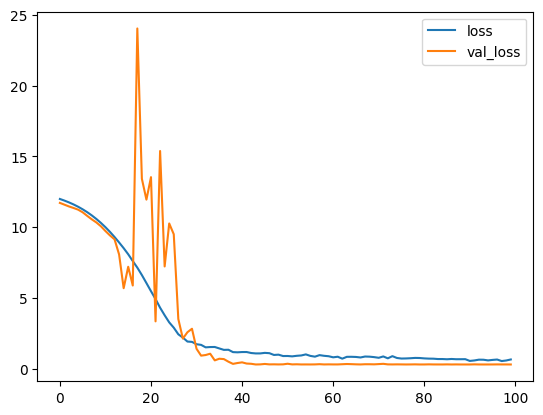

In [218]:
nn_model.compile(
    optimizer='adam',
    loss='mae',
)

history = nn_model.fit(
    train_X, train_y,
    validation_data=(val_X, val_y),
    batch_size=256,
    epochs=100,
    verbose=0,
)


# Show the learning curves
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()

# Final Model and Prediction

In [225]:
final_model = rf_model

In [226]:
final_pred = final_model.predict(test_final)
saleprice_pred = inv_y(final_pred)

# Ensure it's 1D
saleprice_pred = np.ravel(saleprice_pred)

output = pd.DataFrame({'Id': test_final.Id,
                       'SalePrice': saleprice_pred})

output.to_csv('submission.csv', index=False)